Pobieranie danych dla BTC-USD...


[*********************100%***********************]  1 of 1 completed


Trenowanie modelu (Deep Learning)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


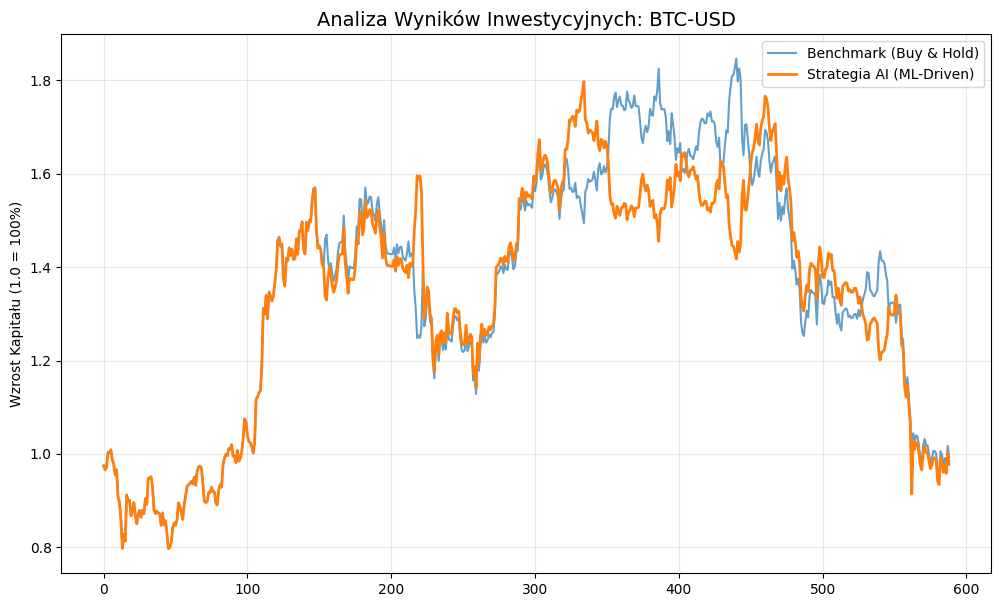


 RAPORT ANALITYCZNY (BACKTEST) 
Total Return   :      -2.19
Sharpe         :       0.21
Max Drawdown   :     -49.13
Win Rate       :      49.41
Sortino        :       0.31


In [1]:
import yfinance as yf
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, BatchNormalization,
                                     MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# KONFIGURACJA
CONFIG = {
    'TICKER': "BTC-USD",
    'START_DATE': "2018-01-01",
    'WINDOW_SIZE': 30,
    'FEE': 0.001,
    'SLIPPAGE': 0.0005,
    'TRAIN_SPLIT': 0.8
}

def get_pro_data(ticker=CONFIG['TICKER']):
    """Pobieranie i zaawansowany Feature Engineering w Polars."""
    raw = yf.download(ticker, start=CONFIG['START_DATE'], auto_adjust=True)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = pl.from_pandas(raw.reset_index())

    # Dodawanie cech istotnych
    df = df.with_columns([
        pl.col("Close").log().alias("Log_Return"),
        (pl.col("Close") / pl.col("Close").shift(1) - 1).alias("Simple_Return"),
        pl.col("Close").rolling_std(window_size=10).alias("Volatility_10d"),
        (pl.col("Volume") / pl.col("Volume").mean()).alias("Relative_Volume"),
        # RSI - wskaźnik siły trendu
        pl.when(pl.col("Close").diff() > 0).then(pl.col("Close").diff()).otherwise(0).alias("Gain"),
        pl.when(pl.col("Close").diff() < 0).then(-pl.col("Close").diff()).otherwise(0).alias("Loss")
    ])

    return df.drop_nulls()

def prepare_sequences(df, window=CONFIG['WINDOW_SIZE']):
    """Skalowanie i przygotowanie danych pod LSTM."""
    features = ["Log_Return", "Volatility_10d", "Relative_Volume"]
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(df.select(features).to_numpy())

    X, y = [], []
    for i in range(window, len(scaled_data)):
        X.append(scaled_data[i-window:i])

        y.append(1 if df["Simple_Return"][i] > 0 else 0)

    return np.array(X), np.array(y), df["Simple_Return"][window:].to_numpy()

def build_attention_model(input_shape):
    """Nowoczesna architektura hybrydowa LSTM + Attention."""
    inputs = Input(shape=input_shape)

    # Warstwa LSTM - wyciąganie zależności czasowych
    x = LSTM(64, return_sequences=True)(inputs)
    x = LayerNormalization()(x)

    # Mechanizm Attention - skupienie na istotnych momentach w oknie czasowym
    attention_out = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = LayerNormalization()(x + attention_out)

    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x) # Binarna klasyfikacja (Góra/Dół)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def calculate_risk_metrics(returns, fees_total):
    """Kluczowe metryki dla analityka biznesowego."""
    cum_returns = np.cumprod(1 + returns)

    # 1. Sharpe Ratio (zakładając risk-free rate = 0)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(365)

    # 2. Maximum Drawdown
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - peak) / peak
    max_drawdown = np.min(drawdown)

    # 3. Win Rate
    win_rate = np.sum(returns > 0) / len(returns)

    # 4. Sortino Ratio
    downside_std = np.std(returns[returns < 0])
    sortino = np.mean(returns) / (downside_std + 1e-9) * np.sqrt(365)

    return {
        "Total Return": (cum_returns[-1] - 1) * 100,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown * 100,
        "Win Rate": win_rate * 100,
        "Sortino": sortino
    }

# Main

print(f"Pobieranie danych dla {CONFIG['TICKER']}...")
df = get_pro_data()
X, y, raw_returns = prepare_sequences(df)

split = int(len(X) * CONFIG['TRAIN_SPLIT'])
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_returns = raw_returns[split:]

print("Trenowanie modelu ...")
model = build_attention_model((CONFIG['WINDOW_SIZE'], X.shape[2]))
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

# --- BACKTESTING I ANALIZA ---

preds = model.predict(X_test).flatten()
# Decyzja: Long (1) jeśli pred > 0.5, Short (-1) w przeciwnym razie
signals = np.where(preds > 0.5, 1, -1)

# Uwzględnienie kosztów (prowizja + poślizg) przy każdej zmianie pozycji
trades = np.diff(signals, prepend=0) != 0
total_costs = CONFIG['FEE'] + CONFIG['SLIPPAGE']
strategy_returns = signals * test_returns - (trades * total_costs)

metrics = calculate_risk_metrics(strategy_returns, total_costs)





plt.figure(figsize=(12, 7))
plt.plot(np.cumprod(1 + test_returns), label='Benchmark (Buy & Hold)', alpha=0.7)
plt.plot(np.cumprod(1 + strategy_returns), label='Strategia AI (ML-Driven)', linewidth=2)
plt.title(f"Analiza Wyników Inwestycyjnych: {CONFIG['TICKER']}", fontsize=14)
plt.ylabel("Wzrost Kapitału (1.0 = 100%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*30)
print(" RAPORT ANALITYCZNY (BACKTEST) ")
print("="*30)
for k, v in metrics.items():
    print(f"{k:<15}: {v:>10.2f}")
print("="*30)